<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [3]:
# Step 2: Industry Distribution

total_records = len(df)
valid_industry = df["Industry"].notna().sum()
missing_industry = df["Industry"].isna().sum()
missing_percentage = df["Industry"].isna().mean() * 100

print("Total records:", total_records)
print("Valid Industry responses:", valid_industry)
print("Missing Industry values:", missing_industry)
print(f"Missing percentage: {missing_percentage:.2f}%")

# Frequency distribution
industry_counts = df["Industry"].value_counts()

display(
    industry_counts
    .rename("Respondents")
    .to_frame()
)

Total records: 65437
Valid Industry responses: 28858
Missing Industry values: 36579
Missing percentage: 55.90%


,Respondents
Industry,
Software Development,11918
Other:,3077
Fintech,1641
"Internet, Telecomm or Information Services",1629
Banking/Financial Services,1371
Healthcare,1277
Manufacturing,1265
Retail and Consumer Services,1264
Government,962


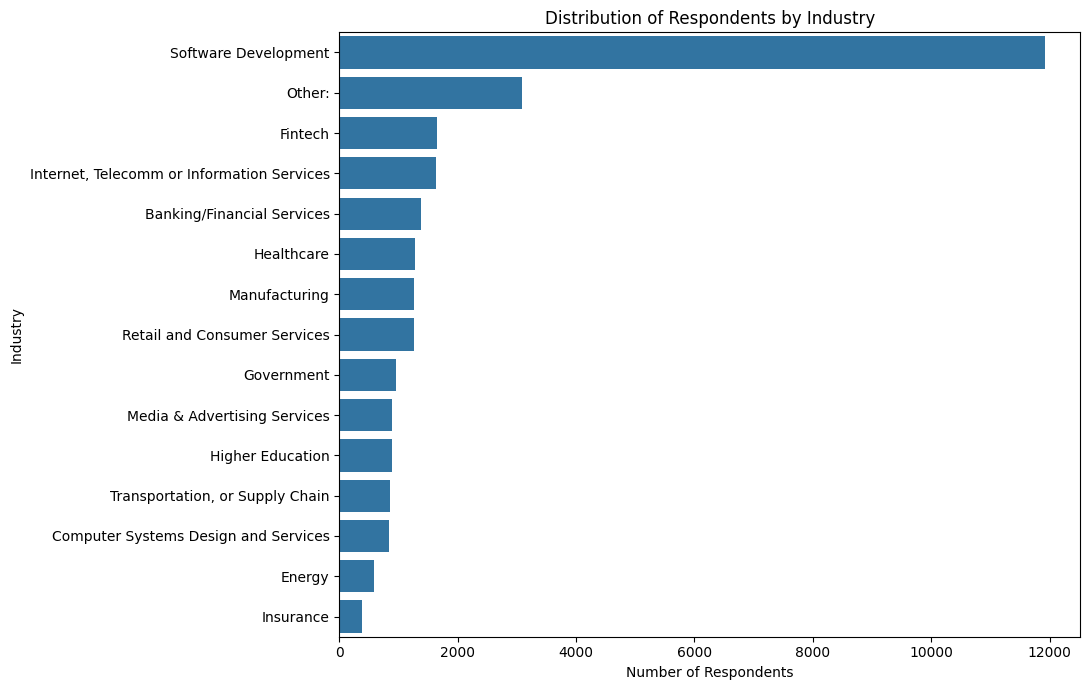

In [4]:
# Bar chart of respondents by industry

plt.figure(figsize=(11, 7))

sns.barplot(
    x=industry_counts.values,
    y=industry_counts.index
)

plt.title("Distribution of Respondents by Industry")
plt.xlabel("Number of Respondents")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

### Analysis – Industry Distribution

The industry distribution shows a clear concentration of respondents in **Software Development**, which is by far the most represented industry in the dataset.

The second-largest category is **Other**, followed by industries such as **Fintech**, **Internet, Telecom or Information Services**, **Banking/Financial Services**, and **Healthcare**.

The remaining industries show progressively smaller numbers of respondents, with **Energy** and **Insurance** among the least represented categories in the visualization.

Overall, the distribution is highly uneven, indicating that the survey sample is strongly dominated by professionals working in software-related environments. This imbalance should be considered when interpreting later analyses, because trends observed in the dataset may reflect the characteristics of software-development respondents more strongly than those of less represented industries.

Missing `Industry` values were excluded only from this visualization and were not imputed or removed from the original dataset.


<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [5]:
# Step 3: Identify High Compensation Outliers

# Convert to numeric without modifying the original dataframe
compensation = pd.to_numeric(
    df["ConvertedCompYearly"],
    errors="coerce"
)

# Data quality
total_records = len(df)
valid_values = compensation.notna().sum()
missing_values = compensation.isna().sum()

print("Total records:", total_records)
print("Valid compensation values:", valid_values)
print("Missing compensation values:", missing_values)
print(f"Missing percentage: {(missing_values / total_records) * 100:.2f}%")

# Basic statistics
mean_comp = compensation.mean()
median_comp = compensation.median()
std_comp = compensation.std()

print(f"\nMean compensation: ${mean_comp:,.2f}")
print(f"Median compensation: ${median_comp:,.2f}")
print(f"Standard deviation: ${std_comp:,.2f}")

# Threshold: 3 standard deviations above the mean
upper_threshold = mean_comp + (3 * std_comp)

print(f"\nUpper outlier threshold: ${upper_threshold:,.2f}")

# Identify high compensation outliers
high_outliers = df.loc[
    compensation > upper_threshold,
    ["ResponseId", "ConvertedCompYearly"]
].copy()

high_outliers = high_outliers.sort_values(
    "ConvertedCompYearly",
    ascending=False
)

print("High compensation outliers:", len(high_outliers))
print(
    f"Percentage of valid compensation records: "
    f"{(len(high_outliers) / valid_values) * 100:.2f}%"
)

display(high_outliers.head(20))

Total records: 65437
Valid compensation values: 23435
Missing compensation values: 42002
Missing percentage: 64.19%

Mean compensation: $86,155.29
Median compensation: $65,000.00
Standard deviation: $186,756.97

Upper outlier threshold: $646,426.21
High compensation outliers: 89
Percentage of valid compensation records: 0.38%


,ResponseId,ConvertedCompYearly
15837,15838,16256603.0
12723,12724,13818022.0
28379,28380,9000000.0
17593,17594,6340564.0
17672,17673,4936778.0
19267,19268,3367716.0
23694,23695,2584118.0
33720,33721,2237846.0
34523,34524,2153432.0
13763,13764,2048046.0


### Analysis – High Compensation Outliers

The `ConvertedCompYearly` variable contains **23,435 valid compensation records**, while **42,002 observations are missing**, representing **64.19% of the dataset**. Missing values were excluded from the statistical calculations but were not imputed or removed from the original dataset.

Among the valid observations, the average yearly compensation is **$86,155.29**, while the median is considerably lower at **$65,000.00**. This difference indicates that the distribution is **right-skewed**, meaning that a relatively small number of very high compensation values are pulling the mean upward.

The standard deviation is **$185,756.97**, which is large relative to both the mean and median. This further confirms that compensation values are widely dispersed and that some observations are substantially higher than the typical respondent's compensation.

Using the criterion defined in the exercise:

**Upper Outlier Threshold = Mean + 3 × Standard Deviation**

the resulting threshold is **$643,426.21**.

A total of **89 respondents** reported compensation above this threshold, representing approximately **0.38% of the valid compensation records**. Some of these observations exceed several million dollars, with the highest values reaching more than **$16 million annually**.

These observations are therefore classified as **potential high-compensation outliers** under the three-standard-deviation rule. However, an extreme value should not automatically be treated as an error. Compensation may legitimately vary substantially because of country, seniority, executive roles, currency conversion, bonuses, or other factors.

For this reason, the identified observations should be investigated further before deciding whether they should be removed, capped, transformed, or retained in subsequent analyses.

Overall, the results show that `ConvertedCompYearly` has a strongly right-skewed distribution with a small number of extremely high values that can substantially influence statistics such as the mean and standard deviation.


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [6]:
# Step 4: Detect Outliers in ConvertedCompYearly using IQR

# Work only with valid compensation values
compensation = pd.to_numeric(
    df["ConvertedCompYearly"],
    errors="coerce"
).dropna()

# Quartiles
Q1 = compensation.quantile(0.25)
Q3 = compensation.quantile(0.75)

# Interquartile Range
IQR = Q3 - Q1

# Outlier boundaries
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"Q1 (25th percentile): ${Q1:,.2f}")
print(f"Q3 (75th percentile): ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")

print(f"\nLower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")

# Identify outliers
lower_outliers = compensation[compensation < lower_bound]
upper_outliers = compensation[compensation > upper_bound]

total_outliers = len(lower_outliers) + len(upper_outliers)

print(f"\nLower outliers: {len(lower_outliers)}")
print(f"Upper outliers: {len(upper_outliers)}")
print(f"Total outliers: {total_outliers}")

print(
    f"Percentage of valid compensation records classified as outliers: "
    f"{(total_outliers / len(compensation)) * 100:.2f}%"
)

Q1 (25th percentile): $32,712.00
Q3 (75th percentile): $107,971.50
IQR: $75,259.50

Lower bound: $-80,177.25
Upper bound: $220,860.75

Lower outliers: 0
Upper outliers: 978
Total outliers: 978
Percentage of valid compensation records classified as outliers: 4.17%


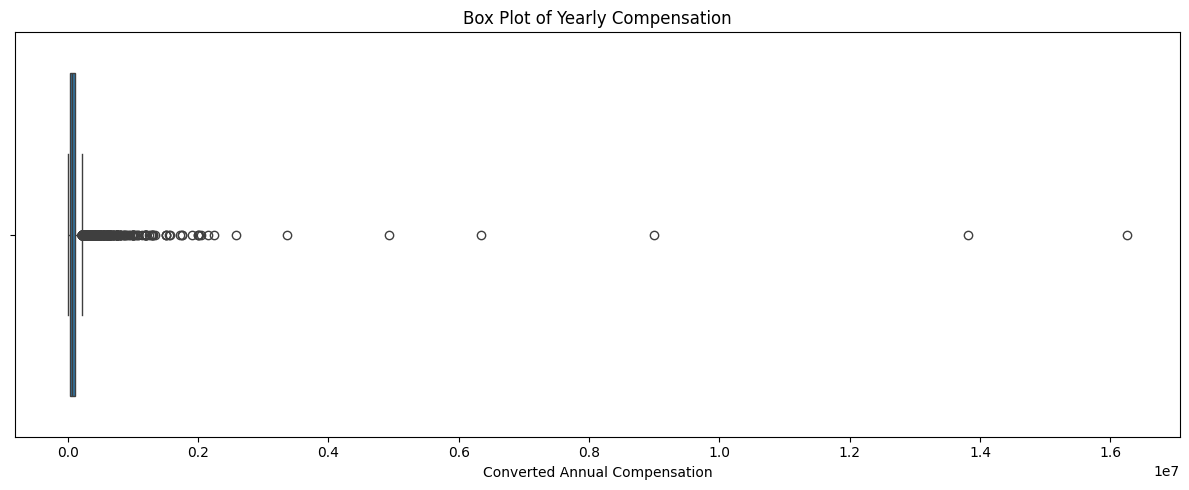

In [7]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    x=compensation
)

plt.title("Box Plot of Yearly Compensation")
plt.xlabel("Converted Annual Compensation")

plt.tight_layout()
plt.show()

### Analysis – Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method was used to identify potential outliers in `ConvertedCompYearly`.

The IQR represents the range containing the middle **50% of the compensation values** and is calculated as:

**IQR = Q3 − Q1**

where:

* `Q1` represents the 25th percentile.
* `Q3` represents the 75th percentile.
* Values below `Q1 − 1.5 × IQR` are considered potential lower outliers.
* Values above `Q3 + 1.5 × IQR` are considered potential upper outliers.

This method is particularly appropriate for compensation data because the distribution is strongly right-skewed. Unlike methods based on the mean and standard deviation, the IQR is less influenced by extremely large salary values.

### Box Plot Interpretation

The box plot provides a visual representation of the compensation distribution.

The **box** represents the middle 50% of the observations, from Q1 to Q3. The line inside the box represents the **median compensation**.

The **whiskers** extend toward the lowest and highest observations that remain within the IQR-based limits.

Any individual points appearing beyond the whiskers are classified as **potential outliers**.

For this dataset, the presence of numerous observations beyond the upper whisker would indicate that the compensation distribution has a long right tail and contains respondents with substantially higher compensation than the majority of the sample.

These observations should not automatically be considered errors. They represent statistically unusual values according to the IQR rule and should be evaluated before deciding whether they should be removed from subsequent analysis.


<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [8]:
# Step 5: Remove compensation outliers

# Numeric compensation series
compensation = pd.to_numeric(
    df["ConvertedCompYearly"],
    errors="coerce"
)

# Keep:
# 1. Missing compensation values
# 2. Values inside the IQR boundaries
keep_mask = (
    compensation.isna()
    | compensation.between(lower_bound, upper_bound)
)

# Create a new DataFrame
df_no_outliers = df.loc[keep_mask].copy()

# Validate results
print("Original dataset rows:", len(df))
print("New dataset rows:", len(df_no_outliers))
print("Rows removed as outliers:", len(df) - len(df_no_outliers))

print("\nOriginal columns:", df.shape[1])
print("New dataset columns:", df_no_outliers.shape[1])

print(
    "Missing compensation values preserved:",
    df_no_outliers["ConvertedCompYearly"].isna().sum()
)

Original dataset rows: 65437
New dataset rows: 64459
Rows removed as outliers: 978

Original columns: 114
New dataset columns: 114
Missing compensation values preserved: 42002


In [9]:
# Validate that compensation outliers were removed

clean_compensation = pd.to_numeric(
    df_no_outliers["ConvertedCompYearly"],
    errors="coerce"
)

remaining_outliers = (
    (clean_compensation < lower_bound)
    | (clean_compensation > upper_bound)
).sum()

print("Remaining compensation outliers:", remaining_outliers)

Remaining compensation outliers: 0


Only observations where ConvertedCompYearly fell below the lower bound or above the upper bound were removed. The original DataFrame (df) was preserved, allowing the cleaned dataset to be compared with the original data and preventing irreversible modifications.

An important distinction was made between outliers and missing values. Records with NaN values in ConvertedCompYearly were retained because a missing compensation response does not represent an extreme compensation value and therefore should not be classified as an outlier.

The resulting DataFrame contains the same variables as the original dataset but excludes compensation observations considered statistically extreme under the IQR criterion.

A final validation was performed to verify that no compensation values outside the previously defined IQR boundaries remained in the cleaned dataset.

This approach reduces the influence of extreme compensation values on subsequent statistical analyses while preserving respondents whose compensation information is missing or falls within the expected distribution.

It is also important to recognize that removing an outlier does not necessarily mean that the original value was incorrect. The removal is performed specifically to create a dataset that is less influenced by extreme observations for the analyses that follow.

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


Age mapping used:


,Age,AgeNumeric
0,Under 18 years old,17.0
3,18-24 years old,21.0
14,25-34 years old,29.5
1,35-44 years old,39.5
2,45-54 years old,49.5
23,55-64 years old,59.5
48,65 years or older,65.0
30,Prefer not to say,NaN


Valid Age values: 64138
Missing/unmapped Age values: 321

Numerical variables included:
['CompTotal', 'WorkExp', 'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat', 'AgeNumeric']

Correlation of Age with numerical variables:


,Pearson Correlation
WorkExp,0.848530
ConvertedCompYearly,0.371556
JobSatPoints_10,-0.112720
JobSatPoints_11,-0.106338
JobSatPoints_5,-0.100816
JobSatPoints_7,-0.081377
JobSatPoints_9,-0.080869
JobSatPoints_4,-0.075343
JobSat,0.067792
JobSatPoints_6,-0.049861


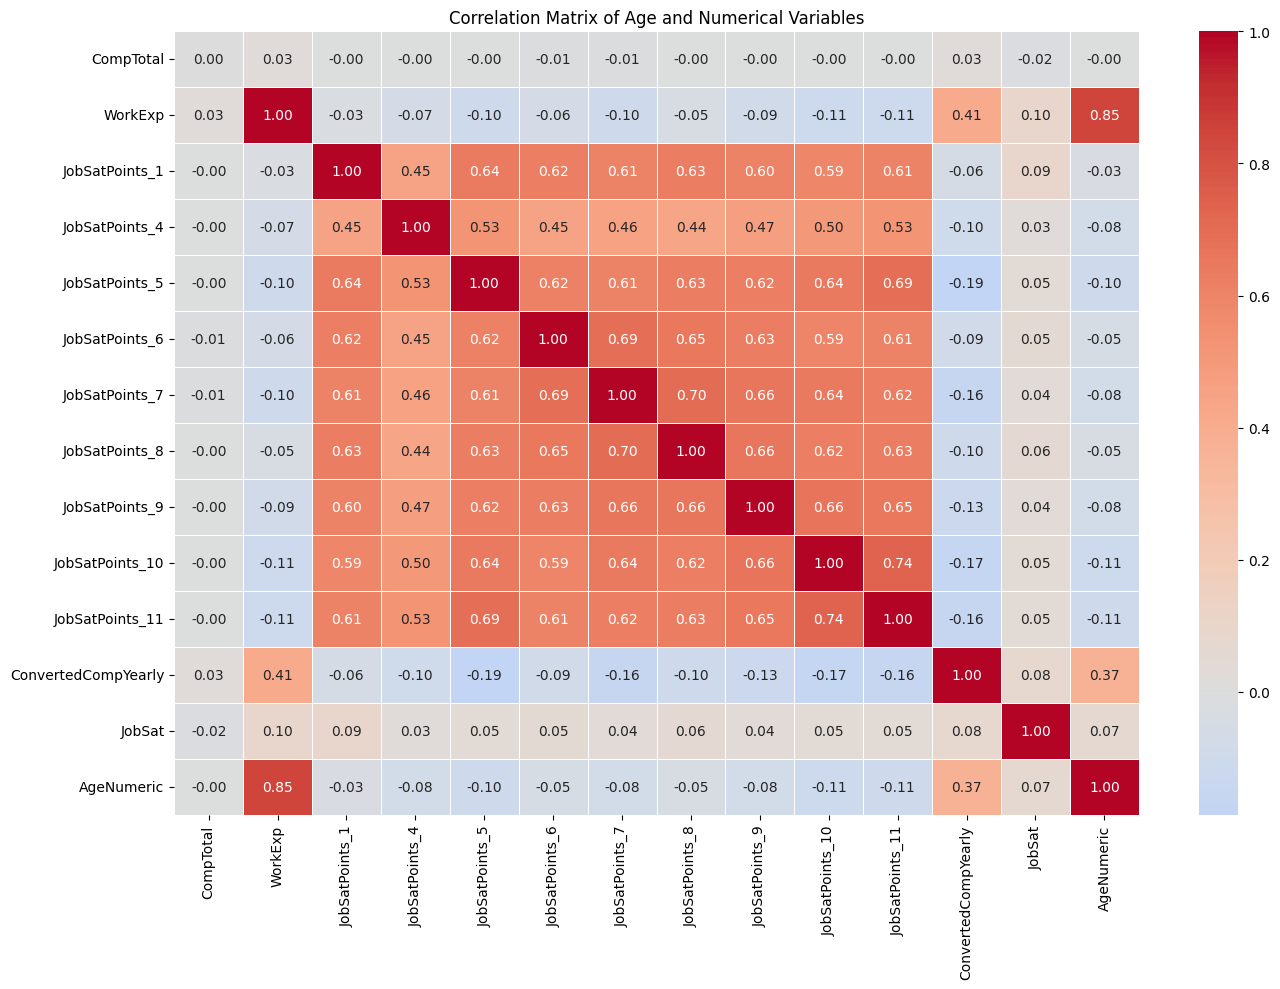

In [11]:
# Step 6: Correlation Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Create a copy so df_no_outliers remains unchanged
# ---------------------------------------------------------

df_corr = df_no_outliers.copy()


# ---------------------------------------------------------
# 2. Convert Age categories to approximate numeric values
# ---------------------------------------------------------

def convert_age_to_numeric(age):
    
    if pd.isna(age):
        return np.nan
    
    age = str(age).strip()
    
    # If Age is already numeric
    try:
        return float(age)
    except ValueError:
        pass
    
    # Common Stack Overflow age categories
    age_mapping = {
        "Under 18 years old": 17,
        "18-24 years old": 21,
        "25-34 years old": 29.5,
        "35-44 years old": 39.5,
        "45-54 years old": 49.5,
        "55-64 years old": 59.5,
        "65 years or older": 65,
        "Prefer not to say": np.nan
    }
    
    return age_mapping.get(age, np.nan)


df_corr["AgeNumeric"] = (
    df_corr["Age"]
    .apply(convert_age_to_numeric)
)


# ---------------------------------------------------------
# 3. Validate Age transformation
# ---------------------------------------------------------

age_validation = (
    df_corr[["Age", "AgeNumeric"]]
    .drop_duplicates()
    .sort_values("AgeNumeric")
)

print("Age mapping used:")
display(age_validation)

print("Valid Age values:", df_corr["AgeNumeric"].notna().sum())
print("Missing/unmapped Age values:", df_corr["AgeNumeric"].isna().sum())


# ---------------------------------------------------------
# 4. Select numerical variables
# ---------------------------------------------------------

numeric_columns = df_corr.select_dtypes(
    include=np.number
).columns.tolist()

# ResponseId is an identifier, not an analytical variable
if "ResponseId" in numeric_columns:
    numeric_columns.remove("ResponseId")

print("\nNumerical variables included:")
print(numeric_columns)


# ---------------------------------------------------------
# 5. Calculate Pearson correlation matrix
# ---------------------------------------------------------

correlation_matrix = (
    df_corr[numeric_columns]
    .corr(method="pearson")
)

print("\nCorrelation of Age with numerical variables:")

age_correlations = (
    correlation_matrix["AgeNumeric"]
    .drop("AgeNumeric")
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    age_correlations
    .rename("Pearson Correlation")
    .to_frame()
)


# ---------------------------------------------------------
# 6. Visualize correlation matrix
# ---------------------------------------------------------

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Age and Numerical Variables")
plt.tight_layout()
plt.show()

### Analysis – Correlation Between Age and Numerical Variables

The correlation matrix shows how `AgeNumeric` relates to the other numerical variables in the dataset after transforming the original age categories into approximate numeric values.

The strongest relationship involving age is with `WorkExp`, with a **Pearson correlation of 0.85**. This indicates a strong positive linear relationship: older respondents tend to report more years of work experience, which is consistent with the expected progression of professional experience over time.

`AgeNumeric` also shows a **moderate positive correlation of 0.37 with `ConvertedCompYearly`**. This suggests that older respondents tend to report higher yearly compensation, although the relationship is not strong enough to imply that age alone determines compensation. Factors such as seniority, role, location, industry, and specialization may also contribute.

The relationship between age and `JobSat` is very weak, with a correlation of approximately **0.07**. This indicates that age has little linear association with overall job satisfaction in this dataset.

The different `JobSatPoints_*` variables also show weak negative correlations with age, generally around **-0.03 to -0.11**. These values are small and do not suggest a meaningful linear relationship with age.

The heatmap also reveals strong positive correlations among several of the `JobSatPoints_*` variables, with some coefficients above **0.60**. This indicates that these job-satisfaction-related components tend to move together and may be measuring related aspects of the respondent's work experience.

### Interpretation of Pearson Correlation

The matrix uses the **Pearson correlation coefficient**, which measures the strength and direction of a linear relationship between two numerical variables.

Values close to:

* **+1** indicate a strong positive linear relationship.
* **0** indicate little or no linear relationship.
* **-1** indicate a strong negative linear relationship.

In this analysis, the most notable finding is the strong relationship between age and work experience, while age shows only moderate association with compensation and very weak association with job satisfaction.

The results describe association rather than causation. A high correlation does not mean that one variable directly causes changes in another.


<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>
